##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 2

**Group name:** [Databazen🤓]

**Student names & numbers:**
* [Xander UijtdeHaag] - [Student no.100546]
* [Jamie Eversdijk] - [Student no.000101617]
* [Jero den Exter] - [Student no.000100883]


---

## 0. Iteration setup

**Import libraries**

In [28]:
%pip install pandas
%pip install matplotlib
%pip install scikit-learn
%pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


**Load and merge datasets**

Wij hebben besloten de eerste dataset de oude en opgeschoonde dataset te mergen door middel van een left join met de nieuwe dataset de tweede. Dit leek ons het meest logisch omdat je bij een left join die wij hebben gebruikt de eerste dataset alle rijen blijft houden. De rijen uit de tweede dataset in ons geval de nieuwe worden alleen toegevoegd als de Ship_ID in bijde datasets hetzelfde is. Als er een nieuwe Ship_ID in de nieuwe dataset zit wordt die ingevuld met een NAN. De nieuwe kolommen van de tweede dataset worden wel meegenomen. 

Een right join zou ook hebben gekunt maar dan zouden de datasets omgedraaid moeten worden dus df1 zou dan de nieuwe moeten zijn en df2 zou dan de oude clean dataset moeten zijn. 

Een inner join hebben wij niet gedaaan omdat dat alleen de data van de ship_ID pakt die in beide datasets staat. Dit zou onnodige ids verwijderen die wij er nu wel in hebben van de oude schone dataset.

In [23]:
# CODE CELL: import the necessary datasets for this iteration
# Make sure to load your cleaned dataset from Iteration 1 AND the new inspection data for Iteration 2.
# Merge them together based on the Ship_ID.
df1 = pd.read_csv("Data/ships_inventory_cleaned_v1.csv")
df2 = pd.read_csv("Data/ship_inspections_iter2.csv")

merged_df = pd.merge(df1, df2, on="Ship_ID", how="left")

merged_df.to_csv("ship_inspections_iter2_merged.csv", index=False)


In [3]:
df = pd.read_csv('Data/ship_inspections_iter2_merged.csv')

---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation description**

*Describe the problem surrounding the safety inspections. Why is the current process (human estimation/gut feeling) a risk?*

De data van Nebula Brokerage is momenteel niet heel goed. De inventory en de inspectielogboeken staan in aparte bestanden. In de inspectiedata missen veel belangrijke waardes bij Propulsion_Type en Reactor_Power door kapotte sensoren. Er zijn ook signalen dat er illegale overclocked reactors zijn die onveilig zijn. Het grootste probleem is dat er geen duidelijke rating is, waardoor het team van sales niet weet wat ze verkopen.

**Business objective(s)**

*Justify why a standardized, rule-based expert system is needed.*

Het doel is om alle losse data samen te voegen tot 1 dashboard. We moeten een systeem maken dat automatisch een rating geeft waardoor het salesteam sneller en veiliger werkt en illegale schepen er direct uitfiltert.

**Data mining goal(s)**

*Explain what type of modeling task this is and why.*

Dit is een classificatie-taak. We gaan een rule-based model maken dat schepen labelt op basis van regels die we zelf instellen. We gebruiken de Hull_Integrity van de monteurs om te checken of de voorspellingen wel kloppen.

**Success criteria**

*Determine success criteria for this iteration*

-De bestanden zijn goed gemerged en de lege waardes zijn logisch ingevuld.

-Alle illegale reactoren zijn 100% zeker als Critical gelabeld.

-De confusion matrix laat zien dat we geen onveilige schepen per ongeluk als goed labelen.

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Show the summary statistics and describe the new variables (e.g., Propulsion_Type, Reactor_Power, Hull_Integrity). Describe your findings.*

De df describe laat een aantal interessante waardes zien als je naar de count kijkt en de max zie je al snel dat er een aantal reactor power waardes missen dit kan je zien door te kijken naar de count van shipID en die te vergelijken met de count van reactorpower. Dit is handig om te weten omdat we nu al weten dat er veel missende waardes zijn waarmee wij iets moeten doen. Ook valt het op dat het gemiddelde en de 25% 50% en 75% allemaal redelijk laag liggen als je kijkt naar min en max. Dit betekend dat er waarschijnlijk een aantal uitschieters zijn of vooral lagere waardes

In [4]:
# CODE CELL: Show basic statistics and information
df.describe()

,Ship_ID,Galactic_Credits,Model_Cycle,Reactor_Power
count,3.603060e+05,360306.000000,360306.000000,331496.000000
mean,7.311483e+09,19232.728903,7511.284225,71.584092
std,4.381778e+06,14286.210766,9.015043,44.647232
min,7.301583e+09,501.000000,7400.000000,30.000000
25%,7.308096e+09,7950.000000,7508.000000,40.000000
50%,7.312599e+09,15990.000000,7513.000000,60.000000
75%,7.315244e+09,27990.000000,7517.000000,80.000000
max,7.317101e+09,99999.000000,7522.000000,360.000000


Df.dtypes laat ons zien dat er 4 numeric kollommen zijn en de andere zijn objecten. Het gebruiken van df.describe() is dus alleen nuttig voor de numeric kollomen omdat deze de enige zijn met cijfers. Verder weten wij dat de object kolommen waarschijnlijk missende waardes gaan hebben of typfouten ook kunnen er verbanden in deze zitten. De ship_Id hebben we niks aan omdat je daar niet echt mee kan rekenen wij zeggen dus dat deze nominaal is het is uniek maar dat is het ook wel. Galactic Credits is de prijs waarvoor het schip is verkocht en is ratio je kan er mee rekenen en het zou 0 kunnen zijn. Model_Cycle is het bouwjaar en is interval omdat het jaren zijn je zou er mee kunnen rekenen en er is een soort van order. Ship manufacturer is bedrijf dat het schip heeft gemaakt.  Sector Regio in de ruimte waar het schip staat. Hull integrity is status van schip en zit een soort orde in je zou het dus ordinaal kunnen noemen want critical is gevaarlijker als pristine. Reactor Power engine output in terawat is een ratio je kan er mee rekenen en het kan nul zijn. Propulsion_Type technologie van de engine is nominaal er zijn categorien of ja er zijn verschillende soorten.. Ship_class type schip is ook nominaal er zijn verschillende soorten schepen. Door deze informatie weten we waar de data over gaat in deze kollommen en wat het betekend. Ook weten we nu beter hoe we de data kunnen gebruiken om patronen te herkennen.

In [5]:
df.dtypes

Ship_ID                int64
Galactic_Credits       int64
Model_Cycle          float64
Ship_Manufacturer     object
Sector                object
Hull_Integrity        object
Reactor_Power        float64
Propulsion_Type       object
Ship_Class            object
dtype: object

**Visualizations and patterns**

*Discover patterns in the data that will help you determine the inspection rules. Create visualizations that show the relationship between variables like Reactor_Power, Propulsion_Type, Ship_Class on one side, and the target variable Hull_Integrity on the other. Describe any hard rules you discover (e.g., relationships with dangerous reactors or advanced tech).*

We kunnen met deze tabel zien dat sommige ship manufacturers maar 1 type schip maken. Dit is handig om te weten omdat je de missende waardes van dit schip type gelijk kan invullen met deze manufacturer. Een voorbeeld hiervan is Nebula industries die alleen de Graviton Beam heeft gemaakt. Wij hebben er dus voor gekozen om deze ook gelijk in te vullen in de dataset.

In [6]:
df.groupby('Ship_Manufacturer')['Propulsion_Type'].value_counts().unstack().fillna(0)

Propulsion_Type,Antimatter,Graviton Beam,Hyperdrive,Ion Drive,Nuclear Pulse,Plasma Hybrid,Plasma Thruster,Solar Sail
Ship_Manufacturer,,,,,,,,
Bayerische Motoren Wormhole,51.0,0.0,0.0,9681.0,204.0,98.0,0.0,1029.0
Corellian Engineering,0.0,0.0,40971.0,0.0,0.0,0.0,0.0,0.0
Droid Works,1.0,0.0,0.0,8935.0,163.0,9.0,0.0,541.0
Galactic Motors,56.0,0.0,0.0,41368.0,7365.0,539.0,0.0,3449.0
General Mining Corp,1.0,0.0,0.0,9739.0,1761.0,15.0,0.0,995.0
Hondo Systems,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16099.0
Independent Shipwrights,687.0,0.0,0.0,75377.0,1318.0,1011.0,0.0,8149.0
Jumpship Corp,8.0,0.0,0.0,13042.0,130.0,43.0,0.0,736.0
Kuat Drive Yards,0.0,0.0,0.0,0.0,0.0,0.0,25634.0,0.0


Deze verdeling van de Reactor power op de schepen is rechts scheef. Dit betekend dat de meeste schepen een reactor power hebben tussen de 40 en 80 in. Hoe hoger het getal wordt hoe minder schepen deze reactor power hebben. De waardes rond de 360 zijn waarschijnlijk outliers, maar dat kan je niet met zekerheid zeggen. Verder weten we dat het gemiddelde groter zal zijn als de mediaan

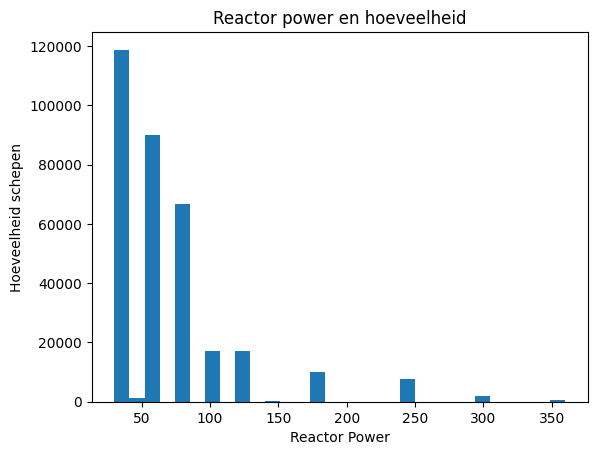

In [7]:
plt.hist(x=df['Reactor_Power'], bins=30)
plt.title('Reactor power en hoeveelheid')
plt.xlabel('Reactor Power')
plt.ylabel('Hoeveelheid schepen')
plt.show()

In deze grafiek hebben wij gekozen om te kijken hoeveel schepen er een bepaalde Reactor Power hebben en dan gelijk te kijken naar de staat van het schip. Hieruit hebben wij gevonden dat alle schepen die boven de 180 Reactor Power in critical state zijn. Dit betekend dat het slecht is voor de schepen om meer dan 180 Reactor power te hebben en dat het schadelijk is. wij hebben voor dit figuur gekozen omdat het makkelijk laat zien per cattegorie van Hull Integrity bij de juiste Reactor power.

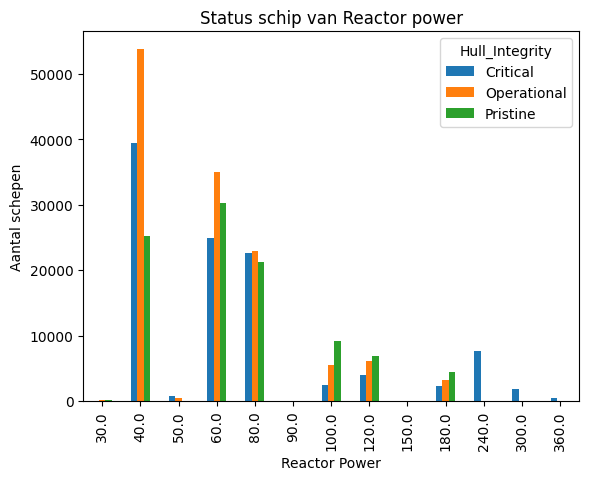

In [8]:
df.groupby('Reactor_Power')['Hull_Integrity'].value_counts().unstack().plot.bar()
plt.xlabel("Reactor Power")
plt.ylabel("Aantal schepen")
plt.title("Status schip van Reactor power")
plt.show()

Deze grafiek laat zien welke model cycle past bij de juiste hull integrity. Je kan duideijk zien dat het geen pristine kan zijn als het boven de 7500 zit. Verder kan et operational en critical zijn als het onder de 7500 is. Er zijn meer critical onder de 7500 als operational. Verder stopt operational ongeveer bij 7425. Wij hebben gekozen voor dit figuur omdat het duidelijk overzicht geeft. Wij denken dat deze het beste past voor deze visualisatie. Dit komt omdat Hull integrity 3 opties heeft en model cycle een hoop meer.

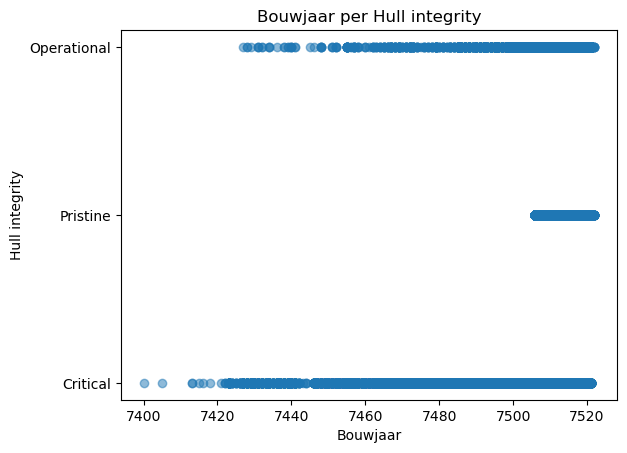

In [8]:
plt.scatter(df['Model_Cycle'], df['Hull_Integrity'], alpha=0.5)
plt.title('Bouwjaar per Hull integrity')
plt.xlabel('Bouwjaar')
plt.ylabel('Hull integrity')
plt.show()

Deze heatmap laat zien wat de gemiddelde prijs is per categorie. Het is duidelijk dat cricital gemiddeld rond de prijs van 10000 zit. Het is wel een gemiddelde en er kan dus veel variatie zijn.

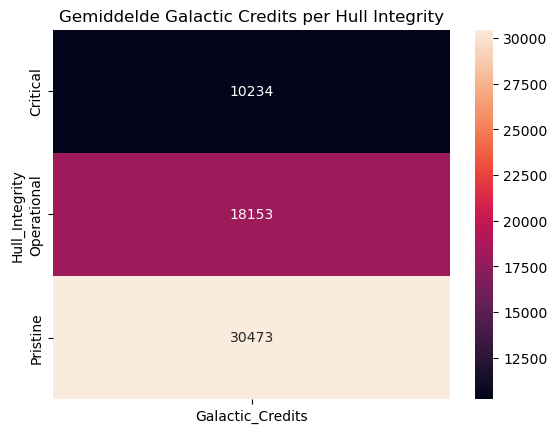

In [18]:
pivot = df.pivot_table(
    index='Hull_Integrity',
    values='Galactic_Credits',
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True, fmt='.0f')

plt.title('Gemiddelde Galactic Credits per Hull Integrity')
plt.show()

In deze grafiek hebben wij een aantal dingen vastgesteld. De plasma thruster zijn het meeste critical. Dit zou kunnen betekenen dat daar de meeste schepen boven de 180 power hebben. De grafiek hieronder laat zien dat dat niet het geval is. Verder heeft de ion drive ook veel criticals dit komt waarschijnlijk omdat hier de meeste schepen van bestaan. Wat we verder kunnen zien is dat Antimatter heel veel pristine heeft vergeleken met critical en operational. Voor de graviton beam is dit hetzelfde. We kunnen dus met dit diagram en het diagram hieronder vaststellen welke hull Integrity elk type schip heeft en welke reactor power het vaakst voorkomt bij dit type schip. We zien hier verder niet echt veel bijzonders. Behalve dat bijna elk schipstype 40 of 60 Reactor power als hoogste waarde heeft. De hyper drive en nuclear Pulse zijn hier de uitzondering in met 80 reator power als hoogste waarde.

Wij hebben besloten deze 2 diagrammen er zo uit te laten zien omdat wij vinden dat je hier een makkelijk overzicht hebt.

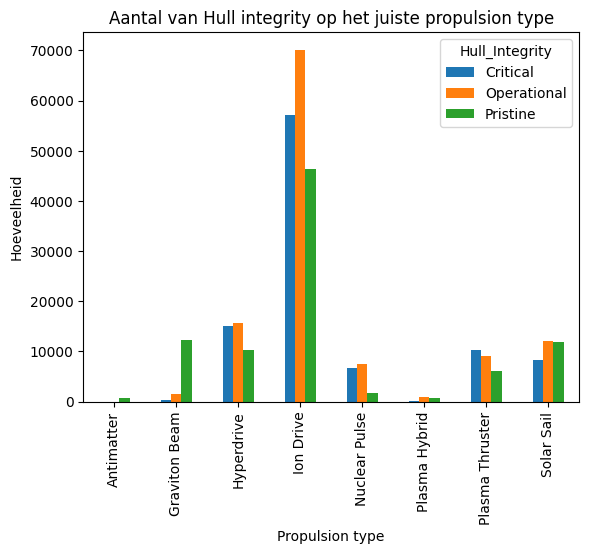

In [9]:
df.groupby('Propulsion_Type')['Hull_Integrity'].value_counts().unstack().plot.bar()
plt.xlabel("Propulsion type")
plt.ylabel("Hoeveelheid")
plt.title("Aantal van Hull integrity op het juiste propulsion type")
plt.show()

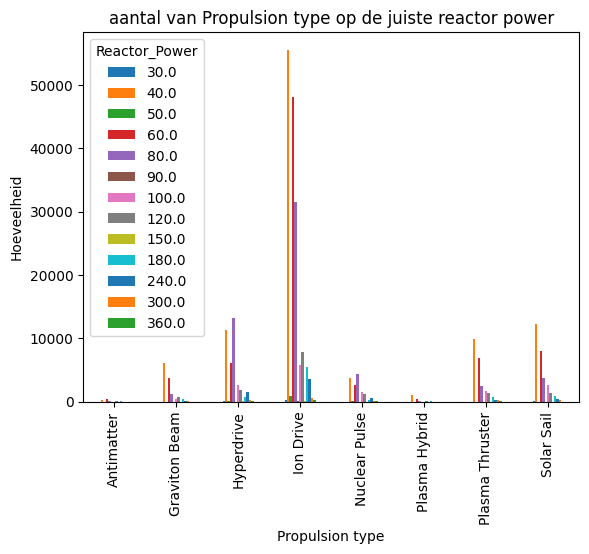

In [10]:
df.groupby('Propulsion_Type')['Reactor_Power'].value_counts().unstack().plot.bar()
plt.xlabel("Propulsion type")
plt.ylabel("Hoeveelheid")
plt.title("aantal van Propulsion type op de juiste reactor power")
plt.show()

**Data insights and data quality**
* **Insights:** What clear rules/patterns did you find that we can use for classification later?
* **Quality issues:** Document missing values (specifically in Propulsion and Reactor) and outliers.

Hieronder zie je wat de missende waardes zijn per kolom. Wij hebben gekozen eerst het getal te laten zien en daara het percentage. Hierdoor weet je hoeveel het percentage daadwerkelijk is. De dataset bevat missende waardes in Reactor Power en Propulsion Type dit zijn de enige waar missende waardes in te vinden zijn. Het percentage van propulsion type is wel erg hoog met 15%.

In [11]:
# CODE CELL: Generate visualizations (e.g., bar charts, boxplots comparing features against Hull_Integrity)
df.isna().sum()

Ship_ID                  0
Galactic_Credits         0
Model_Cycle              0
Ship_Manufacturer        0
Sector                   0
Hull_Integrity           0
Reactor_Power        28810
Propulsion_Type      55420
Ship_Class               0
dtype: int64

Deze grafiek laat zien Hoeveel schepen per propulsion type bij een bepaalde manufacturer hoort. Hieruit kan je belangrijke informatie halen zoals. Corellian Engineering die alleen Hypderdrive schepen heeft. Hondo Systems met alleen Solar Sail, Kuat Drive Yards met alleen Plasme Thruster schepen en Nebula Industries met alleen Graviton Beam schepen. Hieruit kunnen we halen dat wij deze als missende waardes kunnen invullen met 100% zekerheid. Dit hebben wij ook gedaan omdat dit ons de meest logische keuze leek. Verder hebben wij ook niet echt verbanden gevonden buiten deze die ons kan helpen met het uitvinden van propulsion type die mist.

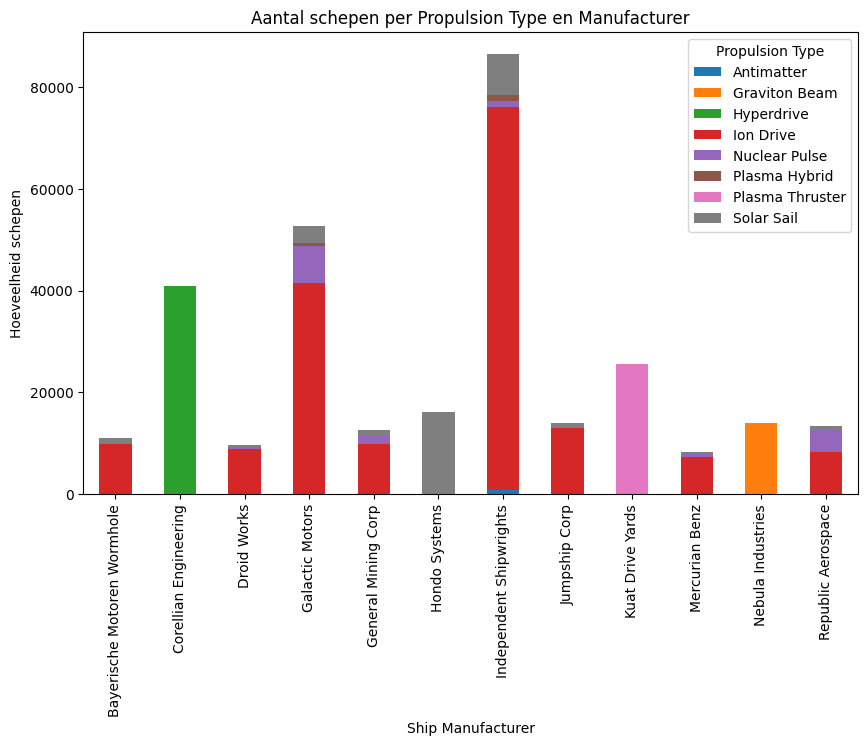

In [12]:
df_counts = df.groupby(['Ship_Manufacturer','Propulsion_Type']).size().unstack(fill_value=0)

df_counts.plot(kind='bar', stacked=True, figsize=(10,6))
plt.xlabel('Ship Manufacturer')
plt.ylabel('Hoeveelheid schepen')
plt.title('Aantal schepen per Propulsion Type en Manufacturer')
plt.legend(title='Propulsion Type')
plt.show()

Dit laat zien hoeveel missende waardes er zijn met procent van het totaal. Dit is handig omdat wij nu weten hoeveel procent van de data mist. Wij weten dat er veel opgevuld moet worden met 15% missende waardes in propulsion type. Ook mist er bijna 8% van de waardes bij reactor power.

In [13]:
df.isna().sum()
df.isna().mean() * 100


Ship_ID               0.000000
Galactic_Credits      0.000000
Model_Cycle           0.000000
Ship_Manufacturer     0.000000
Sector                0.000000
Hull_Integrity        0.000000
Reactor_Power         7.995981
Propulsion_Type      15.381370
Ship_Class            0.000000
dtype: float64

Met deze boxplots kan je outliers zien per Reactor power. Je ziet hier dat Critical de meeste en hoogste outliers heeft vergeleken met de andere types. Dit komt waarschijnlijk omdat de critical status vaak te maken heeft met een hoge Reactor power. Je kan dus vaststellen hiervan dat waarschijnlijk een hoge Reactor power te maken heeft met de critical score. Als je dit vergelijkt met het eerder gemaakt diagram dat gaat over critical score en reactor power weten wij nu zeker dat alle waardes boven de 180 reactor power critical zijn.

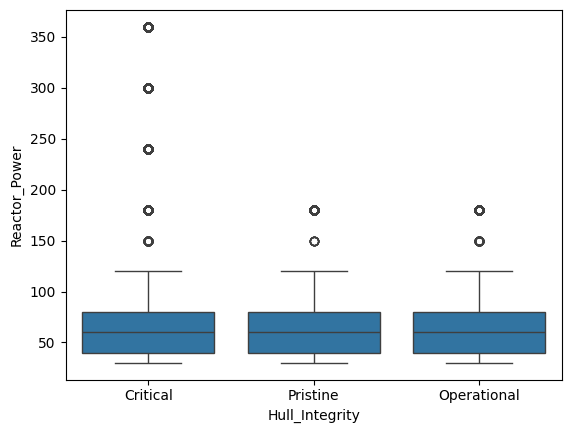

In [14]:
sns.boxplot(x='Hull_Integrity', y='Reactor_Power', data=df)

plt.show()

Er zitten geen duplicated waardes in de dataset. Dit betekend dat die er allemaal al uitgefilterd zijn door de eerste cleanup van iteratie 1. Bij de left join van de nieuwe dataset zou het ook niet echt fout kunnen zijn gegaan omdat die geen duplicaties meegeeft.

In [15]:
df.duplicated().sum()

np.int64(0)

Er staan geen typfouten in de hele dataset.

In [16]:
df['Propulsion_Type'].value_counts()
df['Ship_Manufacturer'].value_counts()
df['Hull_Integrity'].value_counts()
df['Ship_Class'].value_counts()

Ship_Class
Shuttle            122866
Corvette            74204
Explorer            65873
Hauler              39685
Freighter           27682
Fighter             16066
Troop Transport      7402
Speedster            6528
Name: count, dtype: int64

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify how you resolve the missing values.*

Propulsion_Type en Reactor_Power

We hebben eerst alle Manufacturers ingevuld die maar 1 Propulsion type gebruikt en dat kan je vinden in een grafiek in dit vorige hoofdstuk. Als er rond de 5 duizend waardes zijn en allemaal dezelfde Propulsion types bevat per manufacturer, zijn wij ervan uitgegaan dat alle lege dit ook bevatten.

De resterende lege waardes konden wij geen goede correlatie tussen vinden die echt nauwkeurig was. Dus wij hebben besloten om bij propulsion_type alle lege waardes in te vullen met unknown, dit is niet slim om te doen bij kolommen waar numerieke waardes bevat maar dit is bij deze kolom niet het geval. Bij de resterende lege waardes in reactor_power waar wel numerieke waardes in zit, hebben wij besloten om de lege waardes te vullen met de mediaan. aangezien dit de meest middelste getal is in de dataset en in de dataset specifieke getallen voorkomen. Is dit niet slim om bijvoorbeeld met het gemiddelde te doen aangezien dit uit kan komen op een getal wat helemaal niet in Reactor Power kolom zit. 

Illegal Reactors

We hebben onderzocht vanaf welk niveau de Reactor Power als illegal wordt beschouwd., wij zijn erachter gekomen dat vanaf 180 reactor power de hull integrity van alle schepen critical is. Dit betekent dat het schip niet in goede staat is, en dus in deze context als de reactor power hoger dan 180 zijn de schepen automatisch niet in goede staat dus is het vanaf die waarde een illegal reactor.

En tot slot met de df_clean.isna().sum() command kan je zien dat alle lege waardes zijn ingevuld en dus de preparation succesvol is afgerond



In [19]:
# CODE CELL: Data cleaning, preprocessing
# In de bestaande code cell voor Data cleaning, preprocessing (bijvoorbeeld na df.isna().sum())

# Missende Propulsion_Type invullen op basis van Ship_Manufacturer
df_clean = df
# Hier worden de missende Propulsion_Type waarden ingevuld op basis van de Ship_Manufacturer.
df_clean.loc[(df_clean['Ship_Manufacturer'] == 'Corellian Engineering') & (df_clean['Propulsion_Type'].isna()), 'Propulsion_Type'] = 'Hyperdrive'
df_clean.loc[(df_clean['Ship_Manufacturer'] == 'Hondo Systems') & (df_clean['Propulsion_Type'].isna()), 'Propulsion_Type'] = 'Solar Sail'
df_clean.loc[(df_clean['Ship_Manufacturer'] == 'Kuat Drive Yards') & (df_clean['Propulsion_Type'].isna()), 'Propulsion_Type'] = 'Plasma Thruster'
df_clean.loc[(df_clean['Ship_Manufacturer'] == 'Nebula Industries') & (df_clean['Propulsion_Type'].isna()), 'Propulsion_Type'] = 'Graviton Beam'
# Missende waarden van numerieke kolommen vullen met mediaan
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))
# Missende waarden van kolommen met text vullen met 'Unknown'
df_clean['Propulsion_Type'] = df_clean['Propulsion_Type'].fillna('Unknown')

# Omzetten naar csv
df_clean.to_csv("Data/ship_inspections_iter2_cleaned.csv", index=False)

# Controle op missende waarden
df_clean.isna().sum()

Ship_ID              0
Galactic_Credits     0
Model_Cycle          0
Ship_Manufacturer    0
Sector               0
Hull_Integrity       0
Reactor_Power        0
Propulsion_Type      0
Ship_Class           0
dtype: int64

**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [18]:
# OPTIONAL CODE CELL: Additional preprocessing steps

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Build a manual classifier. Use the insights from step 2 to write a Python function with if/elif/else statements that predicts the Hull_Condition for each ship. Apply this function to your dataset and save the predictions in a new column.*

-Critical: Als de Reactor_Power boven de 180 TW komt of als de Model_Cycle lager is dan 7500 of als de Galactic_Credits onder 10000 zijn

-Pristine: Schepen die Antimatter of Graviton Beam als Propulsion_Type hebben,  schepen die meer dan 30000 Galactic_Credits zijn.
-Operational: Alle overige schepen

Justificatie: 
De waarde 180 TW voor Reactor_Power is gekozen is gekozen met hulp van de uitschieters van de dataverkenning, waar we zien dat normale reactoren onder 180 TW blijven. De prijsgrens van 7500 credits is een veiligheidsmarge, heel goedkope schepen zijn vaak het resultaat van verborgen technische problemen. Alle schepen goedkoper dan 10000 zijn bijna allemaal critical. Bijna alle schepen met Antimatter en Graviton Beam zijn pristine en de meeste schepen met Plasma Thruster met een Reactor_Power lager dan 60 zijn pristine, ook zijn hele dure schepen boven 27000 vaak Pristine en nieuwere schepen boven 22000 Galactic_Credits zijn vaak ook Pristine. De overige schpeen die niet voldoen aan de criteria worden geplaatst als operational.

Testing en performance:
We hebben de voorspellingen vergeleken met de Hull_Intergrity van de monteurs. De Confusion Matrix laat zien hoe vaak we de juiste conditie voorspellen. We letten extra goed op het aantal Critical schepen die we per ongeluk als iets anders labelen omdat dit een gevaar is voor het bedrijf.



In [30]:
def predict_perfect_mathematical_condition(row):
    if row['Reactor_Power'] > 180 or row['Model_Cycle'] < 7500 or row['Galactic_Credits'] < 10000:
        return 'Critical'
    
    if row['Propulsion_Type'] in ['Antimatter', 'Graviton Beam']:
        return 'Pristine'

    # if row['Propulsion_Type'] == 'Plasma Thruster' and row['Reactor_Power'] < 60:
    #     return 'Pristine'
    
    if row['Galactic_Credits'] > 30000:
        return 'Pristine'
    
    # if row['Model_Cycle'] > 7515 and row['Galactic_Credits'] > 22000:
    #     return 'Pristine'
    
    return 'Operational'

merged_df['Predicted_Condition'] = merged_df.apply(predict_perfect_mathematical_condition, axis=1)

**Testing and performance**
*Evaluate your manual rules. Calculate the metrics and generate a **confusion matrix** (visualize this using seaborn/matplotlib).*

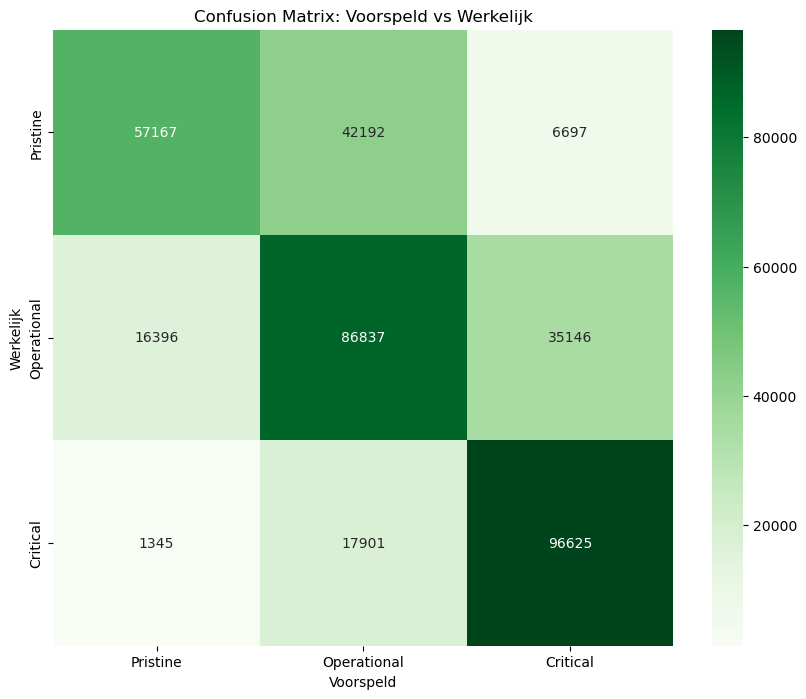

In [31]:
eval_df = merged_df.dropna(subset=['Hull_Integrity'])
y_true = eval_df['Hull_Integrity']
y_pred = eval_df['Predicted_Condition']
labels = ['Pristine', 'Operational', 'Critical']

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.xlabel('Voorspeld')
plt.ylabel('Werkelijk')
plt.title('Confusion Matrix: Voorspeld vs Werkelijk')
plt.show()

---

## 5. Evaluation
*Rubric: LO 6.4C (Results vs. Objectives)*

**Assessment against succes criteria** 
*How well does your manual model identify 'Critical' or 'Pristine' ships? Did you meet the goals set in the Business Understanding?* 
Voor het bereken van hoe accuraat ons model is doen wij deel gedeeld door geheel voor critical doen we dus 96625 / 115871 en dan krijg je een kans van 0.83%. Voor pristine is het 81319 / 106056 dit is dus 0.77% Ons doel was voor 100% weten wat critical is wij hebben ons doel dus niet berijkt. Het doel is wel onrealistisch, want 100% is perfect en niet echt iets wat je kan berijken met een moddel. Verder was de accuracy van het model 250090 / 360306 * 100 = 69.41%. We zaten dus best wel flinks naast ons doel

**Key findings and limitations**
*What are the limitations of a manual, hard-rule-based system? Why might a machine Learning model be better in the next iteration?* De limitaties zijn als er een verandering in de dataset komt kunnen deze regels niet meer gelden. Dit betekent dat er nieuwe regels opgesteld moeten worden. Dit is lastiger om manual te doen, want met machine learning kan je het model trainen op de nieuwe data. Verder kan je manual nu nog redelijk regels toepassen, maar als het complexer wordt gaat dit lastig. Het is dus beter om bij complexere moddels machine learning te gebruiken.

Use [pandas' to_csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html) to export your cleaned and merged dataset for the next iteration. 

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Jero den Exter | Data understanding alle visualisaties gemaakt, Data preperation geholpen met verbanden en logica van de dataset. Evaluation samen met de groep gekeken en logische conclusie gemaakt.| Ik heb geleerd dat het vinden van correlatie best wel lastig kan zijn. Ik liep ook vooral tegen het vinden van de juiste visualizaties. Vaak kwam dit door het verschil tussen classification en regression. Verder heb ik ook geleerd hoe belangrijk correlatie is bij het verbeteren van foute data.Bij het data preperatie stuk vond ik het wel prima om de verbanden uit te leggen en op basis hiervan de dataset te cleanen met Jamie samen. |
| Jamie Eversdijk | Illegal reactor findings, Propulsion type reactor power cleaning | Ik heb geleerd over hoe je ontbrekende waarden moet analyseren en deze moet in vullen op basis van bestaande correlaties tussen bepaalde waardes en hoe ik deze keuzes goed moet onderbouwen. Dit vond ik redelijk lastig aangezien er veel correlaties bestaan maar niet lang niet alle kloppen en zijn logisch dus hier moet je goed onderscheid uit maken. |
| Xander UijtdeHaag | Business Understanding, Modeling | Ik heb nog beter geleerd hoe ik business-problemen vertaalt naar concrete doelen voor data en succescriteria. Bij het maken van het mdoel heb ik geleerd hoe lastig het is om harde regels te schrijven die goed zijn en voor elk schip gelden zonder fouten te maken. Ik heb geleerd dat een model dat simpel lijkt vaak veel complexer is en goed genoeg moet zijn om echt betrouwbaar te zijn voor een bedrijf. Als laatst heb ik veel geleerd over Confusion Matrixes, hoe ik ze maak en waarom ze zo handig zijn voor visualisatie